# 📓 01. Exploratory Data Analysis (EDA) - AI4I 2020 Predictive Maintenance

**Proyek**: Automasi Pipeline Streaming Data Sensor dan Deteksi Anomali Real-Time  
**Tahap**: Hari 1 - Pondasi Data & Eksplorasi  
**Tujuan**: Memahami karakteristik sinyal sensor industri, pola kerusakan mesin, dan merumuskan *feature engineering* untuk model deteksi anomali.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

## 1. Memuat Dataset dan Inspeksi Struktur Data

In [2]:
DATA_PATH = "../data/ai4i2020.csv"
df = pd.read_csv(DATA_PATH)

print(f"Total Baris: {df.shape[0]:,}")
print(f"Total Kolom: {df.shape[1]}")
df.head()

Total Baris: 10,000
Total Kolom: 14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# Cek info tipe data dan nilai yang hilang (missing values)
df.info()
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

## 2. Analisis Target: Ketidakseimbangan Kelas (Class Imbalance)
Dalam sistem prediktif industri nyata, kondisi kerusakan mesin (*failure*) adalah kejadian langka namun berdampak fatal.

Distribusi Kondisi Mesin:
- Normal (0): 9,661 unit (96.61%)
- Kerusakan / Anomali (1): 339 unit (3.39%)


C:\Users\Desman Halawa\AppData\Local\Temp\ipykernel_20596\2741484313.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Machine failure', ax=ax[0], palette=['#10b981', '#ef4444'])
C:\Users\Desman Halawa\AppData\Local\Temp\ipykernel_20596\2741484313.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Normal (0)', 'Mesin Rusak (1)'])


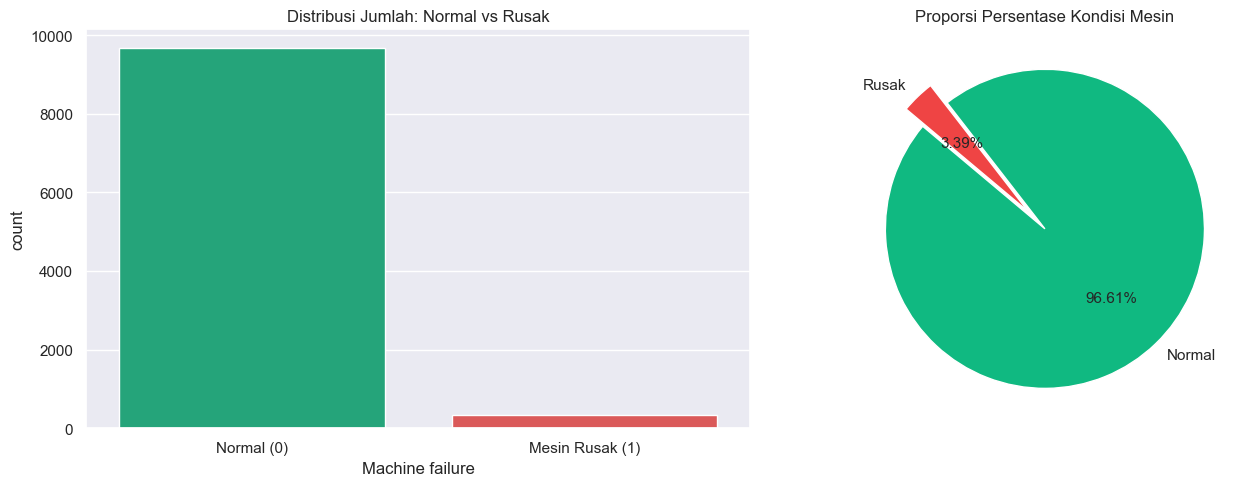

In [4]:
failure_counts = df['Machine failure'].value_counts()
failure_ratio = df['Machine failure'].value_counts(normalize=True) * 100

print("Distribusi Kondisi Mesin:")
for label, count in failure_counts.items():
    status = 'Normal' if label == 0 else 'Kerusakan / Anomali'
    print(f"- {status} ({label}): {count:,} unit ({failure_ratio[label]:.2f}%)")

# Visualisasi Bar Chart
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Machine failure', ax=ax[0], palette=['#10b981', '#ef4444'])
ax[0].set_title("Distribusi Jumlah: Normal vs Rusak")
ax[0].set_xticklabels(['Normal (0)', 'Mesin Rusak (1)'])

ax[1].pie(failure_counts, labels=['Normal', 'Rusak'], autopct='%1.2f%%', colors=['#10b981', '#ef4444'], startangle=140, explode=[0, 0.15])
ax[1].set_title("Proporsi Persentase Kondisi Mesin")
plt.tight_layout()
plt.show()

## 3. Rincian Jenis Kegagalan Mesin
Dataset menyediakan 5 mode kegagalan spesifik:
- **TWF** (*Tool Wear Failure*): Pisau potong tumpul/rusak akibat durasi pemakaian.
- **HDF** (*Heat Dissipation Failure*): Mesin gagal membuang panas operasional.
- **PWF** (*Power Failure*): Pasokan daya tidak seimbang (terlalu rendah/tinggi).
- **OSF** (*Overstrain Failure*): Beban mekanis melampaui toleransi material.
- **RNF** (*Random Failure*): Kerusakan acak yang tidak terpola.

C:\Users\Desman Halawa\AppData\Local\Temp\ipykernel_20596\2329079842.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_per_failure.index, y=counts_per_failure.values, palette='magma')


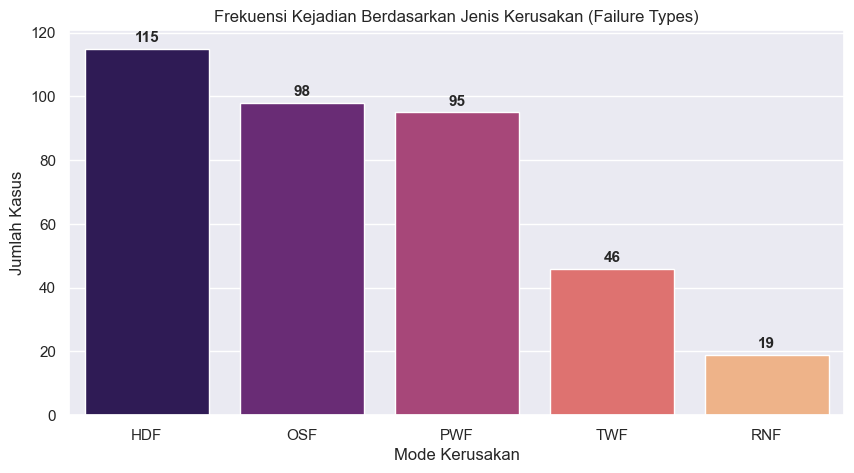

In [5]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
counts_per_failure = df[failure_types].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=counts_per_failure.index, y=counts_per_failure.values, palette='magma')
plt.title("Frekuensi Kejadian Berdasarkan Jenis Kerusakan (Failure Types)")
plt.xlabel("Mode Kerusakan")
plt.ylabel("Jumlah Kasus")
for i, v in enumerate(counts_per_failure.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.show()

## 4. Analisis Hubungan Fitur Fisik Sensor
Meneliti bagaimana sinyal sensor saling berinteraksi, khususnya kecepatan putaran (*Rotational Speed*) vs Gaya Putar (*Torque*).

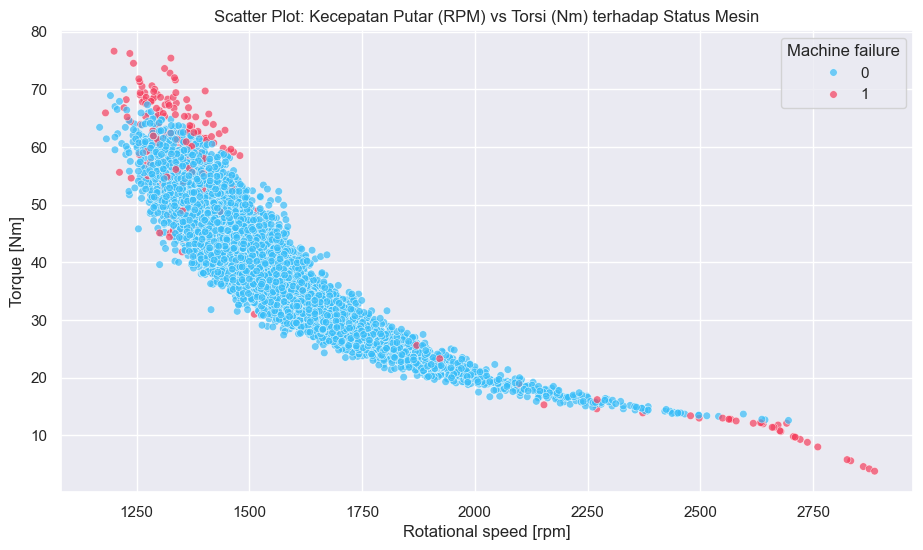

In [6]:
# Hubungan Kecepatan Putaran vs Torsi
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df,
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure',
    palette={0: '#38bdf8', 1: '#f43f5e'},
    alpha=0.7,
    s=30
)
plt.title("Scatter Plot: Kecepatan Putar (RPM) vs Torsi (Nm) terhadap Status Mesin")
plt.show()

## 5. Feature Engineering: Merumuskan Variabel Fisika Baru
Dua fitur turunan penting yang sangat membantu model AI:
1. **Selisih Suhu ($\Delta T$)**: `Process temperature` - `Air temperature` (kunci deteksi HDF)
2. **Daya Mekanis ($Power$)**: $Torque \times \text{Rotational Speed} \times \frac{2\pi}{60}$ (kunci deteksi PWF & OSF)

C:\Users\Desman Halawa\AppData\Local\Temp\ipykernel_20596\292984949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HDF', y='Temp_Difference', ax=ax[0], palette=['#38bdf8', '#f97316'])
C:\Users\Desman Halawa\AppData\Local\Temp\ipykernel_20596\292984949.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PWF', y='Mechanical_Power', ax=ax[1], palette=['#38bdf8', '#ef4444'])


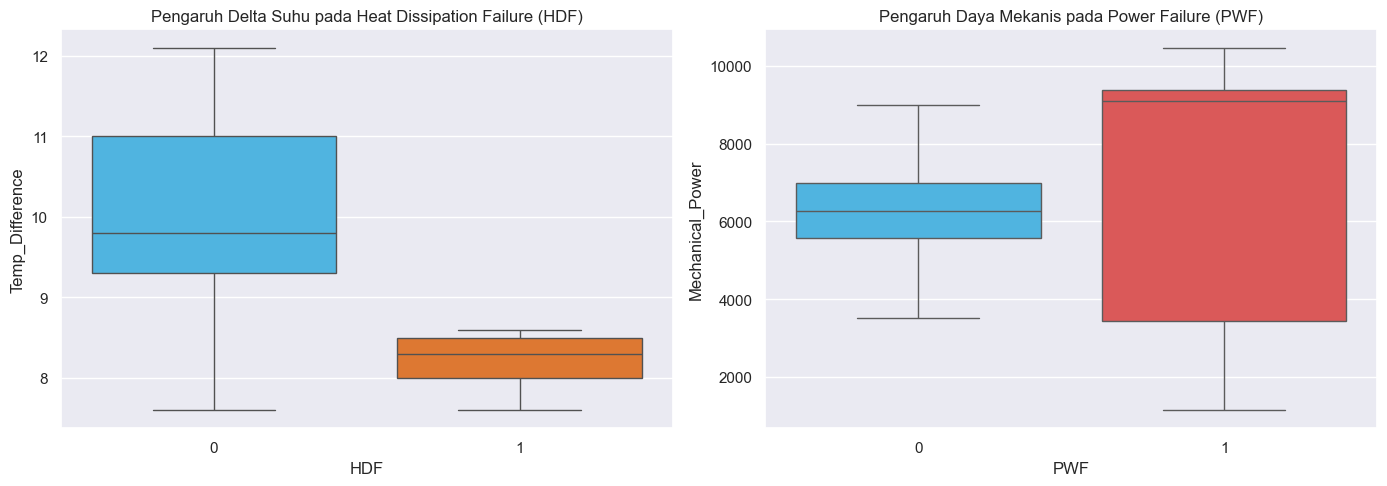

In [7]:
df['Temp_Difference'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Mechanical_Power'] = df['Torque [Nm]'] * (df['Rotational speed [rpm]'] * 2 * np.pi / 60)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='HDF', y='Temp_Difference', ax=ax[0], palette=['#38bdf8', '#f97316'])
ax[0].set_title("Pengaruh Delta Suhu pada Heat Dissipation Failure (HDF)")

sns.boxplot(data=df, x='PWF', y='Mechanical_Power', ax=ax[1], palette=['#38bdf8', '#ef4444'])
ax[1].set_title("Pengaruh Daya Mekanis pada Power Failure (PWF)")
plt.tight_layout()
plt.show()

## 6. Matriks Korelasi (Correlation Heatmap)

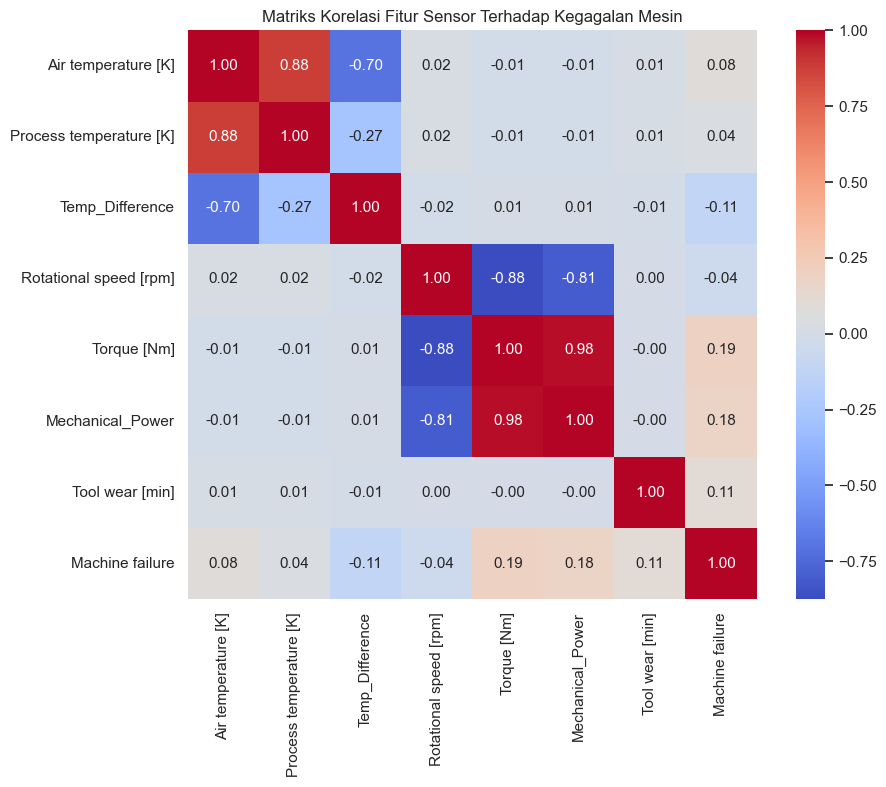

In [8]:
numeric_cols = [
    'Air temperature [K]', 'Process temperature [K]', 'Temp_Difference',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Mechanical_Power',
    'Tool wear [min]', 'Machine failure'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Matriks Korelasi Fitur Sensor Terhadap Kegagalan Mesin")
plt.tight_layout()
plt.show()

## 7. Kesimpulan & Rekomendasi Hari 1 untuk Pelatihan Model di Hari 2

1. **Imbalance Data**: Hanya 3.39% data berkategori rusak. Evaluasi model di Hari 2 wajib menggunakan metrik **PR-AUC, F1-Score, dan Recall**, bukan sekadar akurasi biasa.
2. **Fitur Turunan Efektif**: `Temp_Difference` dan `Mechanical_Power` memiliki pemisahan distribusi yang sangat tegas pada mode kegagalan HDF dan PWF.
3. **Rencana Arsitektur Model Hari 2**:
   - **Deteksi Anomali Umum (Unsupervised)**: Menggunakan **Isolation Forest** untuk mendeteksi outlier operasional tanpa label.
   - **Klasifikasi Kegagalan (Supervised)**: Menggunakan **XGBoost / Random Forest** dengan penyesuaian bobot kelas (`scale_pos_weight`) untuk mendiagnosis jenis kegagalan spesifik.